# Venue activity metrics

Computes a per-venue summary of activity metrics for all 85 TAC Arts venues, and
writes the result to `data/activity/venue_metrics.json` as a list of dictionaries
(one per venue) for easy loading on the frontend.

Metrics computed:

1. Monthly raw stops (scaled x1,000)
2. Monthly unique devices (scaled x1,000)
3. Repeat visitor % by half-year
4. Weekday vs. weekend visit split (%, aggregated over the full period)
5. Daytime (nine-five) vs. evening visit split (%, aggregated over the full period)
6. Home-origin concentration (Herfindahl-Hirschman Index, 0-1 scale)
7. Travel distance distribution (% of unique devices in each distance bucket)


In [1]:
import json
from pathlib import Path

import geohash
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import shape
from tqdm.notebook import tqdm


In [2]:
# --- Paths ---
DATA_DIR = Path("../../data")
ACTIVITY_DIR = DATA_DIR / "activity"
VENUES_DIR = DATA_DIR / "venues" / "tac-list"

VENUE_STOPS_CSV = ACTIVITY_DIR / "venue_stops.csv"
REPEAT_VISITORS_CSV = ACTIVITY_DIR / "venues_repeat_visitors.csv"
HOMES_CSV = ACTIVITY_DIR / "venues_homes.csv"
BOUNDARIES_GEOJSON = VENUES_DIR / "venues-boundaries.geo.json"

OUTPUT_JSON = ACTIVITY_DIR / "venue_metrics.json"

# --- Metric scaling ---
PROP_SCALE = 1_000  # metrics 1 & 2: raw_stop_prop / unique_devices_prop are multiplied by 1,000
PCT_SCALE = 100  # metrics 3, 4, 5: expressed as percentages

# Distance buckets (km) for the home-origin travel distance distribution (metric 7).
# Half-open [lo, hi) ranges so every distance falls in exactly one bucket.
DISTANCE_BUCKETS = [
    ("<1km", 0, 1),
    ("1-3km", 1, 3),
    ("3-10km", 3, 10),
    ("10km+", 10, np.inf),
]
EARTH_RADIUS_KM = 6371.0088

# --- Chart styling (see dataviz skill: fixed categorical order, single-hue sequential) ---
CATEGORICAL_PALETTE = [
    "#2a78d6",  # blue
    "#eb6834",  # orange
    "#1baf7a",  # aqua
    "#eda100",  # yellow
    "#e87ba4",  # magenta
    "#008300",  # green
    "#4a3aa7",  # violet
    "#e34948",  # red
]
SEQUENTIAL_BLUE_RAMP = ["#cde2fb", "#6da7ec", "#2a78d6", "#184f95"]  # light -> dark, ordinal use
CHART_GRID_COLOR = "#e1e0d9"
CHART_MUTED_TEXT = "#898781"


def style_axis(ax):
    """Shared cosmetic cleanup: recessive grid, no top/right spines."""
    ax.grid(axis="y", color=CHART_GRID_COLOR, linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.tick_params(colors=CHART_MUTED_TEXT)


## Load base data

Loads the three activity CSVs, plus the venue boundaries GeoJSON (used later for
metric 7's travel-distance calculation). Venue centroids are computed with
Shapely's area-weighted `centroid` rather than an average-of-vertices, since the
venue polygons are not regular.


In [3]:
venue_stops = pd.read_csv(VENUE_STOPS_CSV)
repeat_visitors = pd.read_csv(REPEAT_VISITORS_CSV)
homes = pd.read_csv(HOMES_CSV)

with open(BOUNDARIES_GEOJSON) as f:
    boundaries = json.load(f)

# venue_id -> (lat, lon) centroid, keyed as int to match the CSVs' venue_id dtype
venue_centroids = {}
for feature in boundaries["features"]:
    venue_id = int(feature["properties"]["id"])
    centroid = shape(feature["geometry"]).centroid
    venue_centroids[venue_id] = (centroid.y, centroid.x)

# Canonical venue_id -> venue_name lookup, and the full list of venues to emit
venue_names = (
    venue_stops[["venue_id", "venue_name"]]
    .drop_duplicates()
    .set_index("venue_id")["venue_name"]
    .to_dict()
)
venue_ids = sorted(venue_names)

print(f"{len(venue_ids)} venues total, {len(venue_centroids)} with a boundary centroid")


85 venues total, 85 with a boundary centroid


## Metrics 1 & 2: monthly raw stops & unique devices

From `venue_stops.csv`, using only `time_period == "all"` rows. Both
`raw_stop_prop` and `unique_devices_prop` are scaled x1,000 per the spec.


In [4]:
stops_all = venue_stops[venue_stops.time_period == "all"].copy()
stops_all["year_month"] = stops_all.year_month.astype(str)
stops_all["raw_stops_scaled"] = stops_all.raw_stop_prop * PROP_SCALE
stops_all["unique_devices_scaled"] = stops_all.unique_devices_prop * PROP_SCALE

monthly_raw_stops = {}
monthly_unique_devices = {}
for venue_id, grp in tqdm(stops_all.groupby("venue_id"), desc="monthly stops/devices"):
    grp = grp.sort_values("year_month")
    monthly_raw_stops[venue_id] = [
        {"year_month": ym, "value": round(v, 6)} for ym, v in zip(grp.year_month, grp.raw_stops_scaled)
    ]
    monthly_unique_devices[venue_id] = [
        {"year_month": ym, "value": round(v, 6)} for ym, v in zip(grp.year_month, grp.unique_devices_scaled)
    ]


monthly stops/devices:   0%|          | 0/85 [00:00<?, ?it/s]

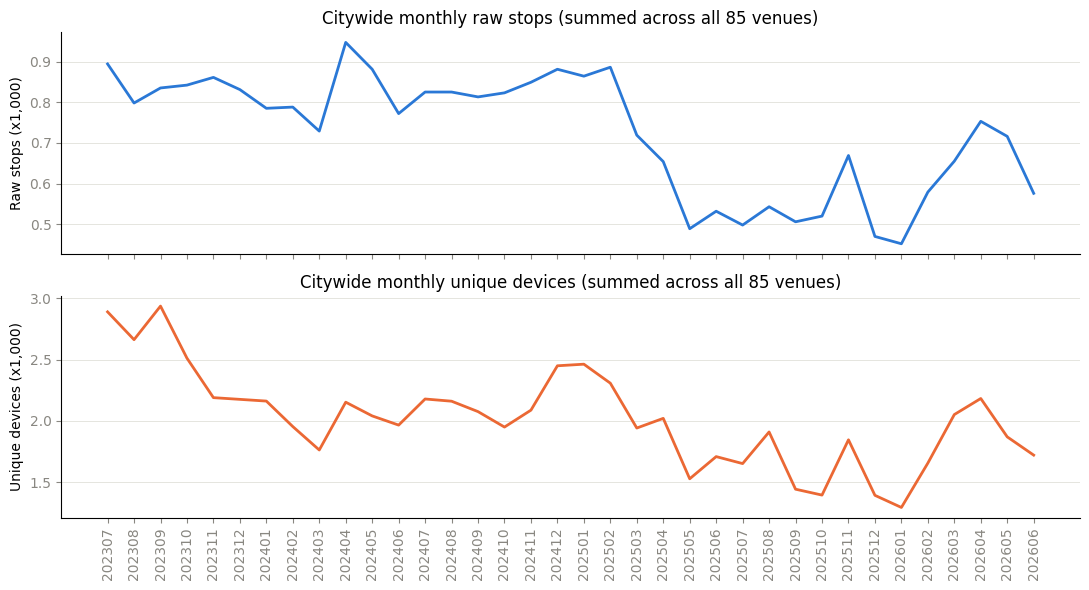

In [5]:
# Summary chart: citywide monthly totals (sanity check, not saved)
monthly_totals = (
    stops_all.groupby("year_month")[["raw_stops_scaled", "unique_devices_scaled"]].sum().sort_index()
)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(monthly_totals.index, monthly_totals.raw_stops_scaled, color=CATEGORICAL_PALETTE[0], linewidth=2)
axes[0].set_title("Citywide monthly raw stops (summed across all 85 venues)")
axes[0].set_ylabel("Raw stops (x1,000)")
style_axis(axes[0])

axes[1].plot(monthly_totals.index, monthly_totals.unique_devices_scaled, color=CATEGORICAL_PALETTE[1], linewidth=2)
axes[1].set_title("Citywide monthly unique devices (summed across all 85 venues)")
axes[1].set_ylabel("Unique devices (x1,000)")
axes[1].tick_params(axis="x", rotation=90)
style_axis(axes[1])

plt.tight_layout()
plt.show()


## Metric 3: repeat visitor % by half-year

From `venues_repeat_visitors.csv`, using only `time_period == "all"` rows.
`repeat_device_prop` is converted to a percentage.


In [6]:
repeat_all = repeat_visitors[repeat_visitors.time_period == "all"].copy()
repeat_all["repeat_pct"] = repeat_all.repeat_device_prop * PCT_SCALE

repeat_visitor_pct = {}
for venue_id, grp in tqdm(repeat_all.groupby("venue_id"), desc="repeat visitors"):
    grp = grp.sort_values("half_year")
    repeat_visitor_pct[venue_id] = [
        {"half_year": hy, "value": round(v, 4)} for hy, v in zip(grp.half_year, grp.repeat_pct)
    ]


repeat visitors:   0%|          | 0/85 [00:00<?, ?it/s]

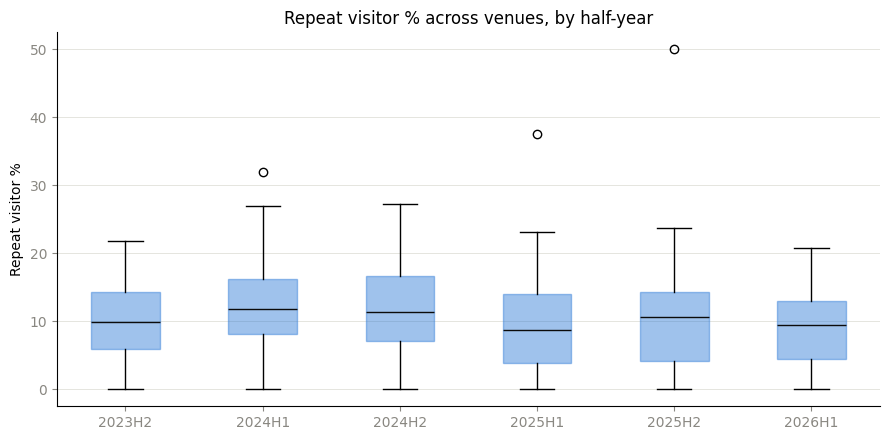

In [7]:
# Summary chart: distribution of repeat visitor % across venues, per half-year
half_years_order = sorted(repeat_all.half_year.unique())
box_data = [repeat_all.loc[repeat_all.half_year == hy, "repeat_pct"].dropna() for hy in half_years_order]

fig, ax = plt.subplots(figsize=(9, 4.5))
bp = ax.boxplot(box_data, tick_labels=half_years_order, patch_artist=True, medianprops={"color": "#0b0b0b"})
for box in bp["boxes"]:
    box.set(facecolor=CATEGORICAL_PALETTE[0], alpha=0.45, edgecolor=CATEGORICAL_PALETTE[0])
ax.set_title("Repeat visitor % across venues, by half-year")
ax.set_ylabel("Repeat visitor %")
style_axis(ax)
plt.tight_layout()
plt.show()


## Metrics 4 & 5: weekday/weekend and daytime/evening splits

From `venue_stops.csv`, using the `weekdays`/`weekends` and `evening`/`nine-five`
`time_period` rows. `raw_stop_count` is summed across the *entire* period
(all year_months) for each venue and each time period, then each pair is
normalized against itself (e.g. `weekday_count / (weekday_count + weekend_count)`)
to get one aggregate split per venue rather than a monthly time series.

Note `evening` + `nine-five` only cover specific windows of the day (not the full
24 hours), so they're only meaningful relative to each other, not against `all`.


In [8]:
period_totals = (
    venue_stops[venue_stops.time_period.isin(["weekdays", "weekends", "evening", "nine-five"])]
    .groupby(["venue_id", "time_period"])["raw_stop_count"]
    .sum()
    .unstack("time_period")
    .reindex(columns=["weekdays", "weekends", "evening", "nine-five"])
    .fillna(0)
)

weekday_weekend_split = {}
daytime_evening_split = {}
for venue_id, row in tqdm(period_totals.iterrows(), total=len(period_totals), desc="weekday/evening splits"):
    wd_total = row["weekdays"] + row["weekends"]
    weekday_weekend_split[venue_id] = (
        {
            "weekday_pct": round(row["weekdays"] / wd_total * PCT_SCALE, 4),
            "weekend_pct": round(row["weekends"] / wd_total * PCT_SCALE, 4),
        }
        if wd_total > 0
        else {"weekday_pct": None, "weekend_pct": None}
    )

    de_total = row["evening"] + row["nine-five"]
    daytime_evening_split[venue_id] = (
        {
            "nine_five_pct": round(row["nine-five"] / de_total * PCT_SCALE, 4),
            "evening_pct": round(row["evening"] / de_total * PCT_SCALE, 4),
        }
        if de_total > 0
        else {"nine_five_pct": None, "evening_pct": None}
    )


weekday/evening splits:   0%|          | 0/85 [00:00<?, ?it/s]

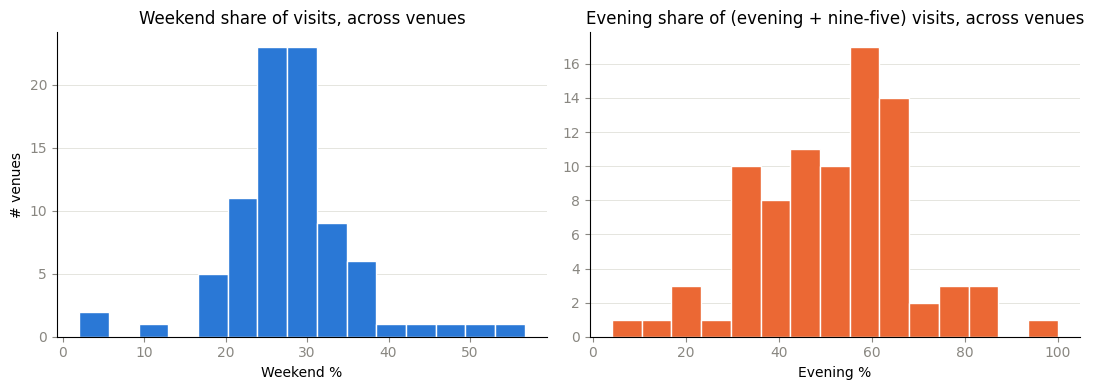

In [9]:
# Summary chart: distribution of weekend % and evening % across venues
weekend_pcts = [v["weekend_pct"] for v in weekday_weekend_split.values() if v["weekend_pct"] is not None]
evening_pcts = [v["evening_pct"] for v in daytime_evening_split.values() if v["evening_pct"] is not None]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(weekend_pcts, bins=15, color=CATEGORICAL_PALETTE[0], edgecolor="white")
axes[0].set_title("Weekend share of visits, across venues")
axes[0].set_xlabel("Weekend %")
axes[0].set_ylabel("# venues")
style_axis(axes[0])

axes[1].hist(evening_pcts, bins=15, color=CATEGORICAL_PALETTE[1], edgecolor="white")
axes[1].set_title("Evening share of (evening + nine-five) visits, across venues")
axes[1].set_xlabel("Evening %")
style_axis(axes[1])

plt.tight_layout()
plt.show()


## Metric 6: home-origin concentration (HHI)

From `venues_homes.csv`, using only `time_period == "all"` rows. For each venue,
the Herfindahl-Hirschman Index is computed over each home geohash's share of
`raw_stop_count`: `HHI = sum(share_i ** 2)`, on a 0-1 scale (1 = all stops come
from a single geohash, near 0 = spread evenly across many geohashes).


In [10]:
homes_all = homes[homes.time_period == "all"].copy()

home_origin_hhi = {}
for venue_id, grp in tqdm(homes_all.groupby("venue_id"), desc="HHI"):
    total = grp.raw_stop_count.sum()
    shares = grp.raw_stop_count / total
    home_origin_hhi[venue_id] = round(float((shares**2).sum()), 6)


HHI:   0%|          | 0/85 [00:00<?, ?it/s]

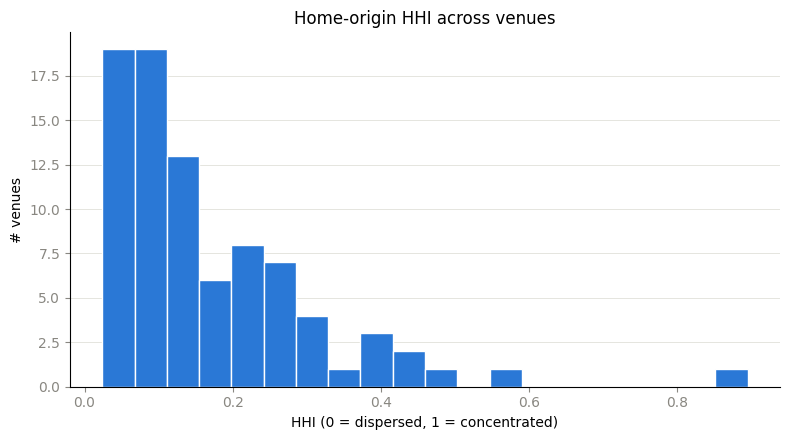

In [11]:
# Summary chart: distribution of home-origin HHI across venues
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(list(home_origin_hhi.values()), bins=20, color=CATEGORICAL_PALETTE[0], edgecolor="white")
ax.set_title("Home-origin HHI across venues")
ax.set_xlabel("HHI (0 = dispersed, 1 = concentrated)")
ax.set_ylabel("# venues")
style_axis(ax)
plt.tight_layout()
plt.show()


## Metric 7: travel distance distribution

For each home geohash6 in `venues_homes.csv` (`time_period == "all"`), compute the
great-circle (haversine) distance from the geohash's decoded center point to the
venue's boundary centroid, bucket it into `<1km`, `1-3km`, `3-10km`, `10km+`, and
report each bucket's share of `unique_devices` as a percentage.

Geohashes are decoded once (there are far fewer unique geohashes than rows) using
`decode_exactly`, which gives the true unrounded cell center rather than the
display-rounded `decode`.


In [12]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = np.radians(lat1), np.radians(lon1), np.radians(lat2), np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * EARTH_RADIUS_KM * np.arcsin(np.sqrt(a))


def bucket_for(distance_km):
    for label, lo, hi in DISTANCE_BUCKETS:
        if lo <= distance_km < hi:
            return label
    return None  # only possible if distance_km is NaN (missing venue centroid)


unique_geohashes = homes_all.home_geohash6.unique()
geohash_centers = {gh: geohash.decode_exactly(gh)[:2] for gh in tqdm(unique_geohashes, desc="decoding geohashes")}

homes_all["home_lat"] = homes_all.home_geohash6.map(lambda g: geohash_centers[g][0])
homes_all["home_lon"] = homes_all.home_geohash6.map(lambda g: geohash_centers[g][1])
homes_all["venue_lat"] = homes_all.venue_id.map(lambda v: venue_centroids[v][0])
homes_all["venue_lon"] = homes_all.venue_id.map(lambda v: venue_centroids[v][1])
homes_all["distance_km"] = haversine_km(
    homes_all.home_lat, homes_all.home_lon, homes_all.venue_lat, homes_all.venue_lon
)
homes_all["distance_bucket"] = homes_all.distance_km.apply(bucket_for)

bucket_labels = [label for label, _, _ in DISTANCE_BUCKETS]
travel_distance_distribution = {}
for venue_id, grp in tqdm(homes_all.groupby("venue_id"), desc="travel distance"):
    total_devices = grp.unique_devices.sum()
    bucket_devices = grp.groupby("distance_bucket").unique_devices.sum()
    travel_distance_distribution[venue_id] = {
        label: round(bucket_devices.get(label, 0) / total_devices * PCT_SCALE, 4) if total_devices > 0 else None
        for label in bucket_labels
    }


decoding geohashes:   0%|          | 0/1182 [00:00<?, ?it/s]

travel distance:   0%|          | 0/85 [00:00<?, ?it/s]

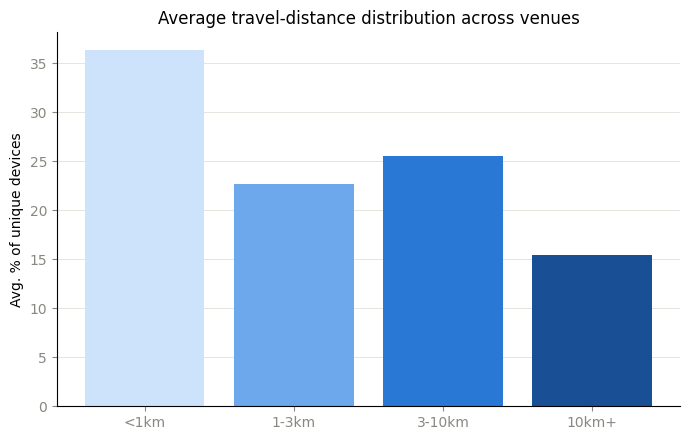

In [13]:
# Summary chart: citywide average travel distance distribution (ordinal -> single-hue ramp)
dist_df = pd.DataFrame(travel_distance_distribution).T[bucket_labels]
avg_by_bucket = dist_df.mean()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(bucket_labels, avg_by_bucket.values, color=SEQUENTIAL_BLUE_RAMP)
ax.set_title("Average travel-distance distribution across venues")
ax.set_ylabel("Avg. % of unique devices")
style_axis(ax)
plt.tight_layout()
plt.show()


## Assemble & write output JSON

Combines all seven metrics into one dictionary per venue and writes the full list
to `data/activity/venue_metrics.json`.


In [14]:
venue_metrics = []
for venue_id in tqdm(venue_ids, desc="assembling JSON"):
    venue_metrics.append(
        {
            "venue_id": venue_id,
            "venue_name": venue_names[venue_id],
            "monthly_raw_stops": monthly_raw_stops.get(venue_id, []),
            "monthly_unique_devices": monthly_unique_devices.get(venue_id, []),
            "repeat_visitor_pct": repeat_visitor_pct.get(venue_id, []),
            "weekday_weekend_split": weekday_weekend_split.get(venue_id, {"weekday_pct": None, "weekend_pct": None}),
            "daytime_evening_split": daytime_evening_split.get(
                venue_id, {"nine_five_pct": None, "evening_pct": None}
            ),
            "home_origin_hhi": home_origin_hhi.get(venue_id),
            "travel_distance_distribution": travel_distance_distribution.get(venue_id),
        }
    )

with open(OUTPUT_JSON, "w") as f:
    json.dump(venue_metrics, f, indent=2)

print(f"Wrote {len(venue_metrics)} venues to {OUTPUT_JSON.resolve()}")


assembling JSON:   0%|          | 0/85 [00:00<?, ?it/s]

Wrote 85 venues to /home/aniket/Programming/eddit-tac/data/activity/venue_metrics.json


In [15]:
# Sanity check: preview one venue's full record
example = next(v for v in venue_metrics if v["venue_name"] == "InterAccess")
print(json.dumps(example, indent=2)[:2000])


{
  "venue_id": 1,
  "venue_name": "InterAccess",
  "monthly_raw_stops": [
    {
      "year_month": "202307",
      "value": 0.005
    },
    {
      "year_month": "202308",
      "value": 0.005
    },
    {
      "year_month": "202309",
      "value": 0.005
    },
    {
      "year_month": "202310",
      "value": 0.004
    },
    {
      "year_month": "202311",
      "value": 0.004
    },
    {
      "year_month": "202312",
      "value": 0.005
    },
    {
      "year_month": "202401",
      "value": 0.005
    },
    {
      "year_month": "202402",
      "value": 0.005
    },
    {
      "year_month": "202403",
      "value": 0.004
    },
    {
      "year_month": "202404",
      "value": 0.009
    },
    {
      "year_month": "202405",
      "value": 0.008
    },
    {
      "year_month": "202406",
      "value": 0.004
    },
    {
      "year_month": "202407",
      "value": 0.004
    },
    {
      "year_month": "202408",
      "value": 0.004
    },
    {
      "year_month": "20